In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
import pandas as pd
df = pd.read_excel('/content/4. Manufacturing data.xlsx')

In [ ]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Cash Compensation     0
Sales                 0
No.of Employees       0
Capital Investment    0
Manufacturing         0
dtype: int64


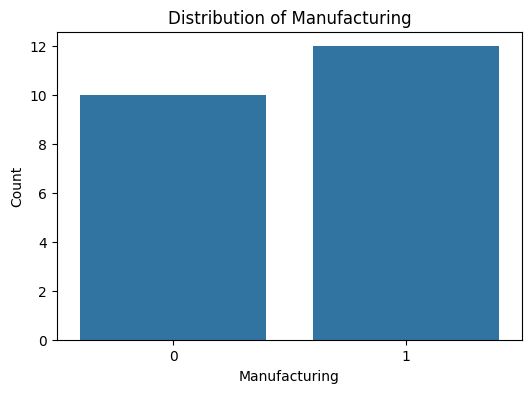

Value counts for the target variable 'Manufacturing':
Manufacturing
1    12
0    10
Name: count, dtype: int64


In [ ]:
# Visualize the target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribution of Manufacturing')
plt.xlabel('Manufacturing')
plt.ylabel('Count')
plt.show()

# Print the value counts
print("Value counts for the target variable 'Manufacturing':")
print(y.value_counts())

In [ ]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display correlations with the target variable 'Manufacturing'
print("Correlation with 'Manufacturing':")
print(correlation_matrix['Manufacturing'].sort_values(ascending=False))

Correlation with 'Manufacturing':
Manufacturing         1.000000
Capital Investment    0.172671
No.of Employees       0.171090
Cash Compensation     0.090179
Sales                 0.053149
Name: Manufacturing, dtype: float64


In [ ]:
# Define independent and dependent variables
X = df[['Cash Compensation', 'Sales', 'No.of Employees', 'Capital Investment']]
y = df['Manufacturing']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training set shape (X_train, y_train):", X_train.shape, y_train.shape)
print("Testing set shape (X_test, y_test):", X_test.shape, y_test.shape)

Training set shape (X_train, y_train): (15, 4) (15,)
Testing set shape (X_test, y_test): (7, 4) (7,)


In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]

In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

[[3 0]
 [0 4]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         4

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7

AUC: 1.0


In [ ]:
coef_df = pd.DataFrame({"Feature": X_train.columns, "Coefficient": np.round(model.coef_[0], 3)})
print(coef_df.sort_values(by="Coefficient", ascending=False))

              Feature  Coefficient
3  Capital Investment        0.361
2     No.of Employees        0.083
0   Cash Compensation       -0.025
1               Sales       -0.628
